In [1]:
#!pip install requests
#!pip install tqdm
#!pip install pandas scikit-learn rapidfuzz tqdm openpyxl python-Levenshtein
#!pip install sentence-transformers
#!pip install hf_xet
#! pip install spacy
#! pip install huggingface_hub==0.10.1
#! pip install --upgrade sentence-transformers
#! pip install sentence-transformers
#! pip install streamlit streamlit_jupyter certifi requests pandas tqdm
#! pip install datasets
#! pip uninstall pyarrow -y
#! pip install pyarrow --upgrade --force-reinstall
#! pip install transformers[torch]

<H1 style="background-color: gold">1-Import Library</H1> 

In [2]:
import os
import re
import time
import certifi
import requests
import torch
import pandas as pd
from tqdm import tqdm
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import xml.etree.ElementTree as ET
import csv
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.cm as cm
import numpy as np
import seaborn as sns
import unicodedata
from rapidfuzz import fuzz, process
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import multiprocessing as mp
from sentence_transformers import SentenceTransformer, util
import concurrent.futures
import random
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
)
import joblib
import warnings
import spacy
from collections import Counter
from collections import deque
import threading
from urllib.parse import urlparse, urlunparse
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import label_binarize



<H1 style="background-color: gold">2-ICD-11 API</H1> 

<h3>2-1-User Interface to Get Data from list Terms</h3>

In [9]:
%%writefile icd_app.py
import streamlit as st
import pandas as pd
import requests, certifi, os, time

from streamlit_jupyter import StreamlitPatcher
StreamlitPatcher().jupyter()   # Run Streamlit inside Jupyter

# --------------------- API Settings ---------------------
CLIENT_ID = "aa84524e-2648-4f35-8107-1d67e5325f29_b7ae6ba1-6572-4f00-b719-2b61007ee5e8"
CLIENT_SECRET = "n1xGam0CyawIt2IvoFy656wrZF6YMJV/lQS1qsT4W2E="
TOKEN_URL = "https://icdaccessmanagement.who.int/connect/token"
SEARCH_URL = "https://id.who.int/icd/entity/search"

OUTPUT_FILE = "search_results.csv"

# --------------------- API Functions ---------------------
def get_access_token():
    data = {
        "client_id": CLIENT_ID,
        "client_secret": CLIENT_SECRET,
        "scope": "icdapi_access",
        "grant_type": "client_credentials"
    }
    headers = {"Content-Type": "application/x-www-form-urlencoded"}
    r = requests.post(TOKEN_URL, data=data, headers=headers, verify=certifi.where())
    r.raise_for_status()
    json_data = r.json()
    if "access_token" not in json_data:
        raise Exception(f"Token not returned: {json_data}")
    return json_data["access_token"]

def search_icd11(term, token):
    headers = {
        "Authorization": f"Bearer {token}",
        "Accept": "application/json",
        "Accept-Language": "en",
        "API-Version": "v2"
    }
    params = {"q": term, "useFlexSearch": "true"}
    r = requests.get(SEARCH_URL, headers=headers, params=params, verify=certifi.where())
    r.raise_for_status()
    data = r.json()
    return data.get("destinationEntities", [])

def fetch_entity_details(uri, token):
    headers = {
        "Authorization": f"Bearer {token}",
        "Accept": "application/json",
        "Accept-Language": "en",
        "API-Version": "v2"
    }
    r = requests.get(uri, headers=headers, verify=certifi.where())
    r.raise_for_status()
    data = r.json()

    title = data.get("title", {}).get("@value") if isinstance(data.get("title"), dict) else None
    definition = data.get("definition", {}).get("@value") if isinstance(data.get("definition"), dict) else None
    synonyms = [s["label"]["@value"] for s in data.get("synonym", []) if isinstance(s.get("label"), dict)]

    # Children URIs
    children = []
    for k in ["child", "children"]:
        for v in data.get(k, []):
            if isinstance(v, dict):
                ch_uri = v.get("@id") or v.get("id") or v.get("uri")
                if ch_uri:
                    children.append(ch_uri)

    # Parent URI
    parent = data.get("parent")
    if isinstance(parent, dict):
        parent_uri = parent.get("@id")
    elif isinstance(parent, list) and len(parent) > 0 and isinstance(parent[0], dict):
        parent_uri = parent[0].get("@id")
    else:
        parent_uri = None

    return {
        "URI": uri,
        "Title": title,
        "Definition": definition,
        "Synonyms": "; ".join(synonyms),
        "Parent_URI": parent_uri,
        "Children": children
    }

# --------------------- Streamlit Interface ---------------------
def run_app():
    st.title("🔍 ICD-11 Foundation Multiline Search Tool")
    st.write("Enter a list of terms, one per line:")

    text_input = st.text_area("Terms:", height=200)

    if st.button("Start Fetching"):
        terms = [t.strip() for t in text_input.split("\n") if t.strip()]
        if not terms:
            st.error("Please enter some terms")
            return

        st.success(f"📌 Number of terms: {len(terms)}")
        token = get_access_token()

        progress = st.progress(0)
        table_placeholder = st.empty()

        # Load existing CSV if available
        if os.path.exists(OUTPUT_FILE):
            df = pd.read_csv(OUTPUT_FILE)
        else:
            df = pd.DataFrame(columns=["Query", "URI", "Title", "Definition", "Synonyms", "Parent_URI", "Children"])

        total = len(terms)
        for i, term in enumerate(terms, start=1):
            search_results = search_icd11(term, token)
            term_entities = []

            for res in search_results:
                uri = res.get("theCode") or res.get("id") or res.get("@id")
                if uri:
                    details = fetch_entity_details(uri, token)
                    details["Query"] = term
                    term_entities.append(details)

            if term_entities:
                df = pd.concat([df, pd.DataFrame(term_entities)], ignore_index=True)
                df.to_csv(OUTPUT_FILE, index=False)

            progress.progress(i / total)
            table_placeholder.dataframe(df)

            time.sleep(0.2)

        st.success("🎉 Fetching completed successfully!")

# --------------------- Run the App ---------------------
run_app()


Overwriting icd_app.py


In [10]:
import subprocess
process = subprocess.Popen(["streamlit", "run", "icd_app.py", "--server.headless=true"])


In [11]:
from IPython.display import IFrame
IFrame(src="http://localhost:8501", width="100%", height=700)

<h3>2-1-Collection Data for diseases for All ICD Entity</h3>

<h4>2-1-1-import MMS Data</h4>

In [14]:
import threading
# ----------------------------
# CONFIG
# ----------------------------
CLIENT_ID = "aa84524e-2648-4f35-8107-1d67e5325f29_b7ae6ba1-6572-4f00-b719-2b61007ee5e8"
CLIENT_SECRET = "n1xGam0CyawIt2IvoFy656wrZF6YMJV/lQS1qsT4W2E="
TOKEN_URL = "https://icdaccessmanagement.who.int/connect/token"

ROOT_URL = "https://id.who.int/icd/release/11/2024-01/mms"

CHECKPOINT_FILE = "ICD11_MMS_checkpoint.csv"
FINAL_FILE = "ICD11_MMS_classification.csv"

# performance tuning
CHECKPOINT_EVERY = 200
SLEEP_BETWEEN_REQUESTS = 0.005   # seconds (5 ms). adjust if you hit rate limits.
SESSION_TIMEOUT = 30
MAX_RETRIES = 5
MAX_WORKERS = 10                 # concurrency: adjust to 5-15 depending on network & API tolerance
BATCH_FETCH_SIZE = 20            # number of queued URIs to submit concurrently in each cycle

# ----------------------------
# helpers: session with retries
# ----------------------------
def make_session(max_retries=MAX_RETRIES):
    session = requests.Session()
    retries = Retry(total=max_retries, backoff_factor=0.5,
                    status_forcelist=[429, 500, 502, 503, 504],
                    allowed_methods=frozenset(["GET", "POST"]))
    adapter = HTTPAdapter(max_retries=retries, pool_connections=MAX_WORKERS, pool_maxsize=MAX_WORKERS)
    session.mount("https://", adapter)
    session.mount("http://", adapter)
    # keep-alive headers
    session.headers.update({
        "Connection": "keep-alive",
        "User-Agent": "ICD11-MMS-Fetcher/1.0"
    })
    return session

# ----------------------------
# token acquisition
# ----------------------------
def get_access_token(session, client_id, client_secret):
    data = {
        "client_id": client_id,
        "client_secret": client_secret,
        "scope": "icdapi_access",
        "grant_type": "client_credentials"
    }
    headers = {"Content-Type": "application/x-www-form-urlencoded"}
    r = session.post(TOKEN_URL, data=data, headers=headers, verify=certifi.where(), timeout=SESSION_TIMEOUT)
    r.raise_for_status()
    tok = r.json().get("access_token")
    if not tok:
        raise RuntimeError("Failed to obtain access token")
    return tok

# ----------------------------
# safe GET JSON
# ----------------------------
def fetch_json(session, url, headers, timeout=SESSION_TIMEOUT):
    # unified fetch with raise_for_status
    r = session.get(url, headers=headers, verify=certifi.where(), timeout=timeout)
    r.raise_for_status()
    return r.json()

# ----------------------------
# Normalization & extraction utils
# ----------------------------
def normalize_uri(u):
    if not u:
        return None
    # if dict passed
    if isinstance(u, dict):
        u = u.get("@id") or u.get("id") or u.get("uri") or u.get("link") or None
        if not u:
            return None

    # strip whitespace
    u = str(u).strip()

    # relative
    if u.startswith("/"):
        u = "https://id.who.int" + u

    # convert http -> https
    if u.startswith("http://"):
        u = "https://" + u[len("http://"):]

    # remove fragment
    parsed = urlparse(u)
    cleaned = parsed._replace(fragment="")

    # sometimes query params cause duplicates: keep base + path + (optional) minimal query if needed
    # here we remove query entirely to reduce duplicate visits
    cleaned = cleaned._replace(query="")

    return urlunparse(cleaned)

def extract_code_from_data(data):
    for k in ("theCode", "Code", "notation", "code", "id"):
        v = data.get(k)
        if v:
            return str(v)
    # sometimes inside 'properties' or nested
    props = data.get("properties") or {}
    for k in ("code", "notation", "theCode"):
        v = props.get(k)
        if v:
            return str(v)
    return None

def extract_title(data):
    t = None
    if "title" in data:
        val = data["title"]
        if isinstance(val, list) and val:
            val = val[0]
        if isinstance(val, dict):
            t = val.get("@value") or val.get("value")
        elif isinstance(val, str):
            t = val
    if not t:
        for k in ("prefLabel", "label", "name"):
            v = data.get(k)
            if isinstance(v, dict):
                t = v.get("@value") or v.get("value")
            elif isinstance(v, str):
                t = v
            if t:
                break
    return t

def extract_definition(data):
    d = None
    if "definition" in data:
        val = data["definition"]
        if isinstance(val, list) and val:
            val = val[0]
        if isinstance(val, dict):
            d = val.get("@value") or d.get("value") if isinstance(d, dict) else val.get("value")
        elif isinstance(val, str):
            d = val
    for k in ("definition_plain", "scopeNote"):
        v = data.get(k)
        if isinstance(v, dict):
            d = v.get("@value") or v.get("value")
        elif isinstance(v, str):
            d = v
        if d:
            break
    return d

# ----------------------------
# CHILD discovery - widened keys
# ----------------------------
POSSIBLE_CHILD_KEYS = [
    "child", "children", "hasPart", "contains", "narrower",
    "member", "members", "items", "browserChildren",
    "classifications", "descendants", "ancestors",
    "inclusions", "exclusions", "postcoordinationScaleEntity",
    "scaleEntityOf", "links", "related", "seeAlso" "hasChildren","pcChildren","pcAxis","scale",
]

def discover_children_from_data(data):
    children = []
    for key in POSSIBLE_CHILD_KEYS:
        cval = data.get(key)
        if not cval:
            continue
        if isinstance(cval, dict):
            cval = [cval]
        if isinstance(cval, list):
            for item in cval:
                # item might be dict or string
                if isinstance(item, dict):
                    # common fields that may contain uris
                    ch = (item.get("@id") or item.get("id") or item.get("uri") or
                          item.get("link") or item.get("stem") or item.get("stemId"))
                else:
                    ch = item
                n = normalize_uri(ch)
                if n:
                  children.append(n)

    # also fallback: sometimes 'member' is an object with nested 'items'
    # we've attempted general coverage above
    return list(dict.fromkeys(children))  # deduplicate preserving order

# ----------------------------
# MAIN fetcher using limited concurrency
# ----------------------------
def fetch_all_mms(root_url, session, headers, checkpoint_file, checkpoint_every=CHECKPOINT_EVERY, progress=None):
    all_entities = []
    visited_uris = set()
    visited_lock = threading.Lock()
    entities_lock = threading.Lock()

    # resume checkpoint
    if os.path.exists(checkpoint_file):
        try:
            df_prev = pd.read_csv(checkpoint_file)
            all_entities = df_prev.to_dict(orient="records")
            visited_uris = set([normalize_uri(r["URI"]) for r in all_entities if r.get("URI")])
            print(f"Resumed from checkpoint: {len(all_entities)} entities loaded.")
        except Exception as e:
            print("Warning: failed to load checkpoint:", e)

    frontier = deque([normalize_uri(root_url)])
    counter = len(all_entities)

    # thread pool for concurrent fetches
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        pbar = progress or tqdm(desc="Downloading ICD-11 MMS (entities)", unit="entity")
        while frontier:
            # build a batch
            batch = []
            while frontier and len(batch) < BATCH_FETCH_SIZE:
                uri = frontier.popleft()
                if not uri:
                    continue
                with visited_lock:
                    if uri in visited_uris:
                        continue
                    visited_uris.add(uri)
                batch.append(uri)

            if not batch:
                continue

            futures = {executor.submit(fetch_json, session, uri, headers): uri for uri in batch}

            for fut in as_completed(futures):
                uri = futures[fut]
                try:
                    data = fut.result()
                except requests.HTTPError as e:
                    status = getattr(e.response, "status_code", None)
                    # If 401/403: raise to caller to allow token refresh
                    if status in (401, 403):
                        raise
                    print(f"HTTPError fetching {uri}: {e}. Skipping for now.")
                    continue
                except Exception as e:
                    print(f"Error fetching {uri}: {e}. Skipping.")
                    continue

                # extract fields
                code = extract_code_from_data(data)
                title = extract_title(data)
                definition = extract_definition(data)

                record = {
                    "Code": code,
                    "Title": title,
                    "Definition": definition,
                    "URI": uri,
                    "Parent_URI": None
                }

                with entities_lock:
                    all_entities.append(record)
                    counter += 1

                # update progress
                pbar.update(1)
                if title:
                    pbar.set_postfix_str(f"{counter} items, last: {str(title)[:30]}")

                # checkpoint periodically
                if counter % checkpoint_every == 0:
                    try:
                        pd.DataFrame(all_entities).to_csv(checkpoint_file, index=False)
                        pbar.set_postfix_str(f"Checkpoint saved ({counter})")
                    except Exception as e:
                        print("Warning: failed saving checkpoint:", e)

                # find and enqueue children
                children = discover_children_from_data(data)
                # ensure normalized & not visited
                for ch in children:
                    n = normalize_uri(ch)
                    if not n:
                        continue
                    with visited_lock:
                        if n not in visited_uris:
                            frontier.append(n)

                # small pacing to be polite (and reduce bright bursts)
                time.sleep(SLEEP_BETWEEN_REQUESTS)

        pbar.close()

    # final save
    try:
        pd.DataFrame(all_entities).to_csv(FINAL_FILE, index=False)
    except Exception as e:
        print("Warning: failed saving final file:", e)
    return all_entities

# ----------------------------
# wrapper with token management & retry on 401/403
# ----------------------------
def fetch_with_token_management():
    session = make_session()
    token = get_access_token(session, CLIENT_ID, CLIENT_SECRET)
    headers = {
        "Authorization": f"Bearer {token}",
        "Accept": "application/json",
        "Accept-Language": "en",
        "API-Version": "v2"
    }

    try:
        entities = fetch_all_mms(ROOT_URL, session, headers, CHECKPOINT_FILE, checkpoint_every=CHECKPOINT_EVERY)
    except requests.HTTPError as e:
        status = getattr(e.response, "status_code", None)
        if status in (401, 403):
            # attempt refresh once
            print("Token invalid/expired. Refreshing token and retrying once...")
            token = get_access_token(session, CLIENT_ID, CLIENT_SECRET)
            headers["Authorization"] = f"Bearer {token}"
            entities = fetch_all_mms(ROOT_URL, session, headers, CHECKPOINT_FILE, checkpoint_every=CHECKPOINT_EVERY)
        else:
            raise
    return entities

# ----------------------------
# utility: print first 10 rows
# ----------------------------
def print_first_10_rows(path):
    if not os.path.exists(path):
        print("File not found:", path)
        return
    df = pd.read_csv(path)
    df.head(10)
    print("\nFirst 10 rows of", path)
    df.head(10)

# ----------------------------
# entrypoint
# ----------------------------
if __name__ == "__main__":
    print("Starting ICD-11 MMS fetch...")
    start = time.time()
    entities = fetch_with_token_management()
    elapsed = time.time() - start
    print(f"\nCompleted fetch: {len(entities)} entities saved to: {FINAL_FILE}")
    print(f"Elapsed time: {elapsed:.1f} seconds")
    print_first_10_rows(FINAL_FILE)

df = pd.read_csv("ICD11_MMS_classification.csv")
df.head(10)


Starting ICD-11 MMS fetch...
Resumed from checkpoint: 36200 entities loaded.



Completed fetch: 36200 entities saved to: ICD11_MMS_classification.csv
Elapsed time: 2.1 seconds



First 10 rows of ICD11_MMS_classification.csv


,Code,Title,Definition,URI,Parent_URI
0,NaN,ICD-11 for Mortality and Morbidity Statistics,NaN,https://id.who.int/icd/release/11/2024-01/mms,NaN
1,01,Certain infectious or parasitic diseases,NaN,https://id.who.int/icd/release/11/2024-01/mms/...,NaN
2,11,Diseases of the circulatory system,NaN,https://id.who.int/icd/release/11/2024-01/mms/...,NaN
3,12,Diseases of the respiratory system,NaN,https://id.who.int/icd/release/11/2024-01/mms/...,NaN
4,13,Diseases of the digestive system,NaN,https://id.who.int/icd/release/11/2024-01/mms/...,NaN
5,03,Diseases of the blood or blood-forming organs,NaN,https://id.who.int/icd/release/11/2024-01/mms/...,NaN
6,14,Diseases of the skin,NaN,https://id.who.int/icd/release/11/2024-01/mms/...,NaN
7,02,Neoplasms,NaN,https://id.who.int/icd/release/11/2024-01/mms/...,NaN
8,15,Diseases of the musculoskeletal system or conn...,NaN,https://id.who.int/icd/release/11/2024-01/mms/...,NaN
9,04,Diseases of the immune system,NaN,https://id.who.int/icd/release/11/2024-01/mms/...,NaN


<h4>2-1-2-Merge MMS With Search Result Terms</h4>

In [14]:
mms = pd.read_csv("ICD11_MMS_classification.csv")
search = pd.read_csv("search_results.csv")

# =========================
# Normalization
# =========================
def normalize(s):
    if pd.isna(s):
        return ""
    return str(s).strip().lower()

mms["Title_norm"] = mms["Title"].apply(normalize)
search["Title_norm"] = search["Title"].apply(normalize)

# =========================
# Matching (Search → MMS)
# =========================
matched_rows = []

print("\nStarting MMS labeling (Exact + Partial)...\n")

for _, s_row in tqdm(search.iterrows(), total=len(search)):

    s_title = s_row["Title_norm"]

    # ---------- Exact Title matches ----------
    exact_matches = mms[mms["Title_norm"] == s_title]

    for _, mms_row in exact_matches.iterrows():
        matched_rows.append({
            "MMS_Code": mms_row.get("Code"),
            "MMS_Title": mms_row.get("Title"),
            "MMS_URI": mms_row.get("URI"),
            "MMS_Parent_URI": mms_row.get("Parent_URI"),

            "Query": s_row.get("Query"),
            "Search_Title": s_row.get("Title"),
            "Search_Definition": s_row.get("Definition"),
            "Search_URI": s_row.get("URI"),
            "Search_Parent_URI": s_row.get("Parent_URI"),
            "Search_Children": s_row.get("Children"),
            "Search_Synonyms": s_row.get("Synonyms"),

            "Match_Type": "Exact Title"
        })

    # ---------- Partial Title matches ----------
    partial_matches = mms[
        (mms["Title_norm"] != s_title) &
        (mms["Title_norm"].str.contains(s_title, regex=False, na=False))
    ]

    for _, mms_row in partial_matches.iterrows():
        matched_rows.append({
            "MMS_Code": mms_row.get("Code"),
            "MMS_Title": mms_row.get("Title"),
            "MMS_URI": mms_row.get("URI"),
            "MMS_Parent_URI": mms_row.get("Parent_URI"),

            "Query": s_row.get("Query"),
            "Search_Title": s_row.get("Title"),
            "Search_Definition": s_row.get("Definition"),
            "Search_URI": s_row.get("URI"),
            "Search_Parent_URI": s_row.get("Parent_URI"),
            "Search_Children": s_row.get("Children"),
            "Search_Synonyms": s_row.get("Synonyms"),

            "Match_Type": "Partial Title"
        })

# =========================
# Save Output
# =========================
matched_df = pd.DataFrame(matched_rows)

matched_df["MMS_Code"] = matched_df["MMS_Code"].apply(
    lambda x: "ICD-11 block title" if pd.isna(x) or str(x).strip() == "" else x
)

matched_df.to_csv("SEARCH_RESULTS_LABELED_BY_MMS.csv", index=False)

print("\nDONE!")
print("Output file: SEARCH_RESULTS_LABELED_BY_MMS.csv")


Starting MMS labeling (Exact + Partial)...



100%|██████████| 3675/3675 [01:05<00:00, 56.01it/s]


DONE!
Output file: SEARCH_RESULTS_LABELED_BY_MMS.csv


<H1 style="background-color: gold">3-Cleaning - Structuring ICD-11</H1> 

In [16]:
file_path = "SEARCH_RESULTS_LABELED_BY_MMS.csv"
df = pd.read_csv(file_path)

# -----------------------------------------------------
# 1) Remove invalid MMS rows
# Keep only rows that actually have MMS_Code or MMS_URI
# -----------------------------------------------------
df = df[~(df["MMS_Title"].notna() & df["MMS_URI"].isna())]

# -----------------------------------------------------
# 2) Clean text columns (trim spaces, remove 'nan')
# -----------------------------------------------------
text_columns = [
    'MMS_Title',
    'Search_Title',
    'Search_Definition',
    'Search_Children',
    'Search_Synonyms',
    'Match_Type'
]

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace({'nan': ''})

# -----------------------------------------------------
# 3) Fill missing values for important columns
# -----------------------------------------------------
fill_columns = [
    'MMS_Code',
    'MMS_URI',
    'MMS_Parent_URI',
    'Search_URI',
    'Search_Parent_URI',
    'Search_Children',
    'Search_Synonyms'
]

for col in fill_columns:
    df[col] = df[col].fillna('')

# -----------------------------------------------------
# 4) Remove duplicates
# (same MMS code + same search entity)
# -----------------------------------------------------
#df = df.drop_duplicates(
#    subset=['MMS_Code', 'Search_URI'],
#    keep='first'
#)

# -----------------------------------------------------
# 5) Reorder final columns
# -----------------------------------------------------
columns_order = [
    'MMS_Code',
    'MMS_Title',
    'MMS_URI',
    'MMS_Parent_URI',

    'Query',
    'Search_Title',
    'Search_Definition',
    'Search_URI',
    'Search_Parent_URI',
    'Search_Children',
    'Search_Synonyms',

    'Match_Type'
]

df = df[columns_order]

# -----------------------------------------------------
# 6) Save cleaned file
# -----------------------------------------------------
clean_file_path = "SEARCH_RESULTS_MMS_CLEANED.csv"
df.to_csv(clean_file_path, index=False)

print(f"Cleaned matching file saved at: {clean_file_path}")

Cleaned matching file saved at: SEARCH_RESULTS_MMS_CLEANED.csv


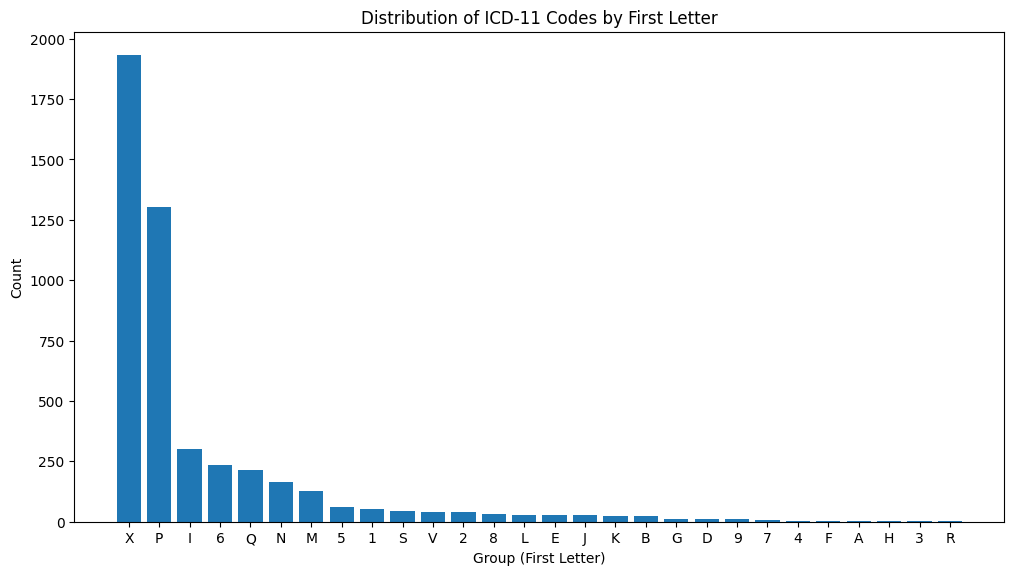

In [17]:
plt.figure(figsize=(12, 14))
plt.subplot(2, 1, 1)
df["Group"] = df["MMS_Code"].astype(str).str[0] 
code_counts = df["Group"].value_counts()
plt.bar(code_counts.index, code_counts.values)
plt.title("Distribution of ICD-11 Codes by First Letter")
plt.xlabel("Group (First Letter)")
plt.ylabel("Count")
plt.show()

<h1 style="background-color: gold">4-Data cleaning for ERC data</h1>

In [18]:
df = pd.read_csv("ERC_Gold_Standard.csv", dtype=str)
# -----------------------------
# 1. Keep only useful columns
# -----------------------------
df = df[[
    "No. / Nr.",
    "English",
    "Subdivision English",
    "Definition Englisch",
    "Including",
    "Excluding"
]].copy()

df.columns = ["Code", "Title", "Subdivision", "Definition","Including" ,"Excluding"]

# Remove useless whitespace
for col in ["Title", "Subdivision", "Definition","Including" ,"Excluding"]:
    df[col] = df[col].fillna("").str.strip()

# -----------------------------
# 2. Remove rows with no Code
# -----------------------------
df = df[df["Code"].notna() & (df["Code"].str.strip() != "")].copy()

# Normalize code like: "A - 1.2" → "A-1.2"
df["Code"] = df["Code"].str.replace(r"\s*-\s*", "-", regex=True)

# Create ERC_ID by removing symbols
df["ERC_ID"] = df["Code"].str.replace(r"[^A-Za-z0-9]", "", regex=True)

# -----------------------------
# 3. Extract Parent using code hierarchy
# -----------------------------
def get_parent(code):
    """
    A-1.2  → parent = A-1
    A-2    → parent = A  (but top-level has no parent)
    """
    if "." in code:
        # remove last level
        return code.rsplit(".", 1)[0]
    else:
        # Top-level: remove last hyphen part (A-1 → A?)
        if "-" in code:
            return code.split("-")[0]
    return None

df["Parent"] = df["Code"].apply(get_parent)

# -----------------------------
# 4. Compute Children mapping
# -----------------------------
children_map = {c: [] for c in df["Code"]}

for code, parent in zip(df["Code"], df["Parent"]):
    if parent in children_map:
        children_map[parent].append(code)

df["Children"] = df["Code"].map(children_map)

# -----------------------------
# 5. Clean text fields
# -----------------------------
def clean_text(x):
    if pd.isna(x):
        return ""
    x = str(x)
    x = re.sub(r"\s+", " ", x)  # normalize whitespace
    x = x.strip()
    return x

df["Title_clean"] = df["Title"].apply(clean_text)
df["Subdivision_clean"] = df["Subdivision"].apply(clean_text)
df["Definition_clean"] = df["Definition"].apply(clean_text)
df["Including_clean"] = df["Including"].apply(clean_text)
df["Excluding_clean"] = df["Excluding"].apply(clean_text)

# -----------------------------
# 6. Reorder columns
# -----------------------------
df = df[[
    "ERC_ID", "Code",
    "Title_clean", "Subdivision_clean", "Definition_clean","Including" ,"Excluding",
    "Parent", "Children"
]]

# -----------------------------
# 7. Save cleaned file
# -----------------------------
output_path = "ERC_cleaned.csv"
df.to_csv(output_path, index=False)

output_path
df.head(10)


,ERC_ID,Code,Title_clean,Subdivision_clean,Definition_clean,Including,Excluding,Parent,Children
0,A1,A-1,Transport accident,,Adverse event in transport resulting in proper...,,,A,"[A-1.1, A-1.2, A-1.3]"
1,A11,A-1.1,Transport accident,Collision,Transport accident involving a collision of ve...,"Vehicle-vehicle collision, vehicle-human colli...",Entrapment,A-1,[]
2,A12,A-1.2,Transport accident,Fall,Transport accident involving a crash of vehicl...,,Collision,A-1,[]
4,A13,A-1.3,Transport accident,Entrapment,Transport accident involving an entrapment of ...,,,A-1,[]
5,A2,A-2,Fall,,An adverse event involving a loss of stability...,,,A,"[A-2.1, A-2.2, A-2.3]"
6,A21,A-2.1,Fall,Fall on the same level or from less than 1 meter*,"Falling downward due to gravity, but without a...","Stumbling, slipping, falling from standing pos...",Falls in/from modes of transport,A-2,[]
7,A22,A-2.2,Fall,Fall from a height of 1 meter or more,"Falling downward due to gravity, with a signif...","Stair, ladder, building",Falls in/from modes of transport,A-2,[]
8,A23,A-2.3,Fall,Fall from unspecified height,"Falling downward due to gravity, where the hei...",,,A-2,[]
9,A3,A-3,Natural disaster,,Adverse event with one or more direct natural ...,,,A,"[A-3.1, A-3.2, A-3.3, A-3.4, A-3.5, A-3.6, A-3..."
10,A31,A-3.1,Natural disaster,Storm,Natural disaster caused by strong wind,Tornado cyclone,,A-3,[]


<H1 style="background-color: gold">5-Semantic Alignment between ICD-11 and ERC without Synonyms/Including/Excluding</H1> 

<h3>5-1-Create Concept Text</h3>

In [19]:
path_icd = "SEARCH_RESULTS_MMS_CLEANED.csv"
path_erc = "ERC_cleaned.csv"
path_gold = "ERC_Gold_Standard.csv"

icd = pd.read_csv(path_icd)
erc = pd.read_csv(path_erc)
gold = pd.read_csv(path_gold)

print("Files loaded:")
print("ICD (Search + MMS):", icd.shape)
print("ERC:", erc.shape)
print("Gold:", gold.shape)

# =========================
# LIGHT NORMALIZATION ONLY
# (keep essential, remove redundancy)
# =========================
def light_clean(text):
    if pd.isna(text):
        return ""
    return str(text).strip().lower()

# Apply only where it matters
icd["Search_Title"] = icd["Search_Title"].apply(light_clean)
icd["Search_Definition"] = icd["Search_Definition"].apply(light_clean)

# =========================
# CREATE CONCEPT TEXT FIELD
# =========================

# ICD concept = Search title + definition + synonyms
icd["concept_text"] = (
    icd["Search_Title"].fillna('') + " " +
    icd["Search_Definition"].fillna('')
).str.replace(r'\s+', ' ', regex=True)

# ERC concept = title + subdivision + definition
erc["concept_text"] = (
    erc["Title_clean"].fillna('') + " " +
    erc["Subdivision_clean"].fillna('') + " " +
    erc["Definition_clean"].fillna('')
).str.replace(r'\s+', ' ', regex=True)

print("\nConcept text created")

# =========================
# SAVE OUTPUT (PHASE 0)
# =========================
icd_filtered_path = "ICD11_Search_MMS_phase0.csv"
erc_filtered_path = "ERC_phase0.csv"

icd.to_csv(icd_filtered_path, index=False)
erc.to_csv(erc_filtered_path, index=False)

print("Saved ICD:", icd_filtered_path)
print("Saved ERC:", erc_filtered_path)

# =========================
# SANITY CHECK
# =========================
print("\nICD concept_text types:")
print(icd["concept_text"].apply(type).value_counts())

print("\nERC concept_text types:")
print(erc["concept_text"].apply(type).value_counts())

Files loaded:
ICD (Search + MMS): (4746, 12)
ERC: (308, 9)
Gold: (332, 12)

Concept text created
Saved ICD: ICD11_Search_MMS_phase0.csv
Saved ERC: ERC_phase0.csv

ICD concept_text types:
concept_text
<class 'str'>    4746
Name: count, dtype: int64

ERC concept_text types:
concept_text
<class 'str'>    308
Name: count, dtype: int64


<h3>5-2-Semantic Alignment using SentenceTransformer Models </h3>

In [20]:
TOP_K = 1
MODEL_NAME = "all-mpnet-base-v2"

# =========================
# LOAD FILES
# =========================
icd = pd.read_csv("ICD11_Search_MMS_phase0.csv")
erc = pd.read_csv("ERC_phase0.csv")

print("ICD:", icd.shape)
print("ERC:", erc.shape)

# =========================
# LOAD MODEL
# =========================
model = SentenceTransformer(MODEL_NAME)

# =========================
# COMPUTE EMBEDDINGS
# =========================
icd_embeddings = model.encode(
    icd["concept_text"].tolist(),
    convert_to_tensor=True,
    normalize_embeddings=True
)

erc_embeddings = model.encode(
    erc["concept_text"].tolist(),
    convert_to_tensor=True,
    normalize_embeddings=True
)

# =========================
# TOP-K MATCHING
# =========================
results = []

for i, erc_row in tqdm(erc.iterrows(), total=len(erc)):

    erc_vec = erc_embeddings[i]
    cos_scores = util.cos_sim(erc_vec, icd_embeddings)[0]

    top_k_scores, top_k_indices = torch.topk(cos_scores, k=TOP_K)

    for rank, (score, idx) in enumerate(zip(top_k_scores, top_k_indices), start=1):

        score = float(score)
        icd_row = icd.iloc[int(idx)]

        # relationship labeling (can be refined later)
        if score >= 0.72:
            relation = "Equivalent"
        elif score >= 0.60:
            relation = "ERC-Narrower"
        elif score >= 0.50:
            relation = "ERC-Broader"
        elif score >= 0.30:
            relation = "Related to"
        else:
            relation = "No match"

        results.append({
            # ERC
            "ERC_ID": erc_row["ERC_ID"],
            "ERC_Title": erc_row["Title_clean"],
            "ERC_Definition": erc_row["Definition_clean"],

            # ICD
            "ICD_MMS_Code": icd_row["MMS_Code"],
            "ICD_MMS_Title": icd_row["MMS_Title"],
            "ICD_Search_Title": icd_row["Search_Title"],
            "ICD_Search_Definition": icd_row["Search_Definition"],

            # Matching info
            "Rank": rank,
            "Similarity_Score": score,
            "Relationship": relation
        })

# =========================
# SAVE RESULTS
# =========================
df_matches = pd.DataFrame(results)
df_matches.to_csv("ERC_ICD_matches_phase1_top.csv", index=False)
df_matches.head(10)


ICD: (4746, 13)
ERC: (308, 10)


100%|██████████| 308/308 [00:02<00:00, 116.34it/s]


,ERC_ID,Code,Title_clean,Subdivision_clean,Definition_clean,Including,Excluding,Parent,Children
0,A1,A-1,Transport accident,,Adverse event in transport resulting in proper...,,,A,"[A-1.1, A-1.2, A-1.3]"
1,A11,A-1.1,Transport accident,Collision,Transport accident involving a collision of ve...,"Vehicle-vehicle collision, vehicle-human colli...",Entrapment,A-1,[]
2,A12,A-1.2,Transport accident,Fall,Transport accident involving a crash of vehicl...,,Collision,A-1,[]
4,A13,A-1.3,Transport accident,Entrapment,Transport accident involving an entrapment of ...,,,A-1,[]
5,A2,A-2,Fall,,An adverse event involving a loss of stability...,,,A,"[A-2.1, A-2.2, A-2.3]"
6,A21,A-2.1,Fall,Fall on the same level or from less than 1 meter*,"Falling downward due to gravity, but without a...","Stumbling, slipping, falling from standing pos...",Falls in/from modes of transport,A-2,[]
7,A22,A-2.2,Fall,Fall from a height of 1 meter or more,"Falling downward due to gravity, with a signif...","Stair, ladder, building",Falls in/from modes of transport,A-2,[]
8,A23,A-2.3,Fall,Fall from unspecified height,"Falling downward due to gravity, where the hei...",,,A-2,[]
9,A3,A-3,Natural disaster,,Adverse event with one or more direct natural ...,,,A,"[A-3.1, A-3.2, A-3.3, A-3.4, A-3.5, A-3.6, A-3..."
10,A31,A-3.1,Natural disaster,Storm,Natural disaster caused by strong wind,Tornado cyclone,,A-3,[]


<H3>5-3-Initial evaluation of samples based on matching terminology identifiers</H3>

Prediction: (310, 10)
Gold: (332, 12)
Evaluation pairs: 9

====== FINAL GOLD EVALUATION (CODE + RELATION) ======
Pairs evaluated : 9
Accuracy        : 0.778
Precision       : 0.679
Recall          : 0.625
F1-score        : 0.625


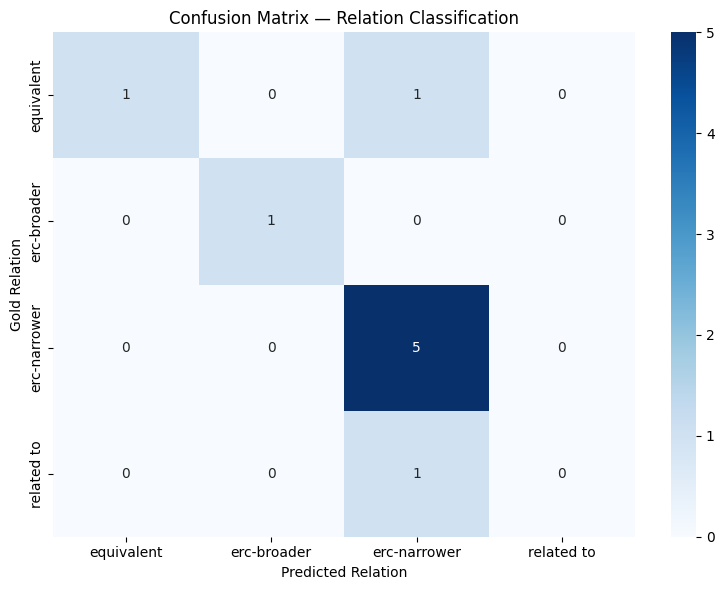

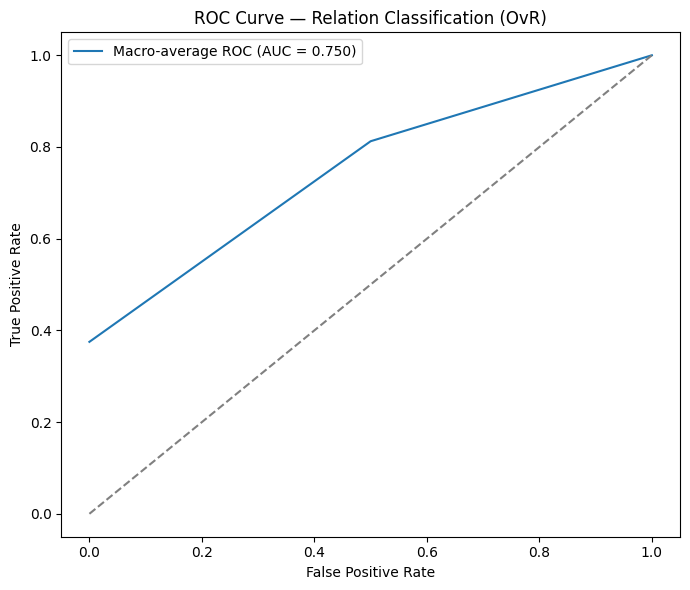

ROC AUC (macro-average): 0.750


In [25]:
pred = pd.read_csv("ERC_ICD_matches_phase1_topk.csv", dtype=str).fillna("")
gold = pd.read_csv("ERC_Gold_Standard.csv", dtype=str).fillna("")

print("Prediction:", pred.shape)
print("Gold:", gold.shape)

# =========================
# NORMALIZE IDS & CODES
# =========================
def norm(x):
    return str(x).strip().lower().replace(" ", "").replace("-", "")

pred["ERC_ID_norm"] = pred["ERC_ID"].apply(norm)
pred["ICD_Code_norm"] = pred["ICD_MMS_Code"].apply(norm)

gold["ERC_ID_norm"] = gold["No. / Nr."].apply(norm)
gold["ICD_Code_norm"] = gold["ICD-11 Code"].apply(norm)

# =========================
# KEEP ONLY COMMON ERC–ICD PAIRS
# =========================
pred["PAIR_KEY"] = pred["ERC_ID_norm"] + "||" + pred["ICD_Code_norm"]
gold["PAIR_KEY"] = gold["ERC_ID_norm"] + "||" + gold["ICD_Code_norm"]

common_pairs = set(pred["PAIR_KEY"]) & set(gold["PAIR_KEY"])

pred_eval = pred[pred["PAIR_KEY"].isin(common_pairs)].copy()
gold_eval = gold[gold["PAIR_KEY"].isin(common_pairs)].copy()

print("Evaluation pairs:", pred_eval.shape[0])

# =========================
# MERGE FOR EVALUATION
# =========================
df = pred_eval.merge(
    gold_eval[["PAIR_KEY", "Levels of equivalence"]],
    on="PAIR_KEY",
    how="inner"
)

# =========================
# RELATION COMPARISON ONLY
# =========================
df["Pred_Rel"] = df["Relationship"].str.strip().str.lower()
df["Gold_Rel"] = df["Levels of equivalence"].str.strip().str.lower()

df["Correct"] = df["Pred_Rel"] == df["Gold_Rel"]

# =========================
# METRICS
# =========================
accuracy = df["Correct"].mean()

precision = precision_score(
    df["Gold_Rel"], df["Pred_Rel"],
    average="macro", zero_division=0
)

recall = recall_score(
    df["Gold_Rel"], df["Pred_Rel"],
    average="macro", zero_division=0
)

f1 = f1_score(
    df["Gold_Rel"], df["Pred_Rel"],
    average="macro", zero_division=0
)

print("\n====== EVALUATION (CODE + RELATION) ======")
print(f"Pairs evaluated : {df.shape[0]}")
print(f"Accuracy        : {accuracy:.3f}")
print(f"Precision       : {precision:.3f}")
print(f"Recall          : {recall:.3f}")
print(f"F1-score        : {f1:.3f}")
print("====================================================")

# ======================================================
# CONFUSION MATRIX (RELATIONS)
# ======================================================
labels = sorted(set(df["Gold_Rel"]) | set(df["Pred_Rel"]))

cm = confusion_matrix(
    df["Gold_Rel"], df["Pred_Rel"],
    labels=labels
)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=labels,
    yticklabels=labels,
    cmap="Blues"
)
plt.title("Confusion Matrix — Relation Classification")
plt.xlabel("Predicted Relation")
plt.ylabel("Gold Relation")
plt.tight_layout()
plt.show()

# ======================================================
# ROC CURVE + AUC (MULTICLASS — ONE VS REST)
# ======================================================
le = LabelEncoder()
y_true = le.fit_transform(df["Gold_Rel"])
y_pred = le.transform(df["Pred_Rel"])

# Binarize labels
classes = np.unique(y_true)
y_true_bin = label_binarize(y_true, classes=classes)
y_pred_bin = label_binarize(y_pred, classes=classes)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i, cls in enumerate(classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in classes]))
mean_tpr = np.zeros_like(all_fpr)

for i in classes:
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= len(classes)
macro_auc = auc(all_fpr, mean_tpr)

# Plot ROC
plt.figure(figsize=(7,6))
plt.plot(all_fpr, mean_tpr, label=f"Macro-average ROC (AUC = {macro_auc:.3f})")
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Relation Classification (OvR)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"ROC AUC (macro-average): {macro_auc:.3f}")

<h3>5-4-Final Gold Evaluation – Relation</h3>

In [3]:

PRED_FILE = "ERC_ICD_matches_phase1_topk.csv"
GOLD_FILE = "ERC_Gold_Standard.csv"

pred = pd.read_csv(PRED_FILE, dtype=str).fillna("")
gold = pd.read_csv(GOLD_FILE, dtype=str).fillna("")
def norm(x):
    return (
        str(x)
        .strip()
        .lower()
        .replace(" ", "")
        .replace("-", "")
        .replace(".", "")
    )

pred["ERC_norm"] = pred["ERC_ID"].apply(norm)
pred["ICD_norm"] = pred["ICD_MMS_Code"].apply(norm)
pred["REL_norm"] = pred["Relationship"].astype(str).str.strip().str.lower()

gold["ERC_norm"] = gold["No. / Nr."].apply(norm)
gold["ICD_norm"] = gold["ICD-11 Code"].apply(norm)
gold["REL_norm"] = gold["Levels of equivalence"].astype(str).str.strip().str.lower()

pred["PAIR_KEY"] = pred["ERC_norm"] + "||" + pred["ICD_norm"]
gold["PAIR_KEY"] = gold["ERC_norm"] + "||" + gold["ICD_norm"]
# KEEP ONLY COMMON PAIRS
common_pairs = set(pred["PAIR_KEY"]) & set(gold["PAIR_KEY"])

pred_eval = pred[pred["PAIR_KEY"].isin(common_pairs)]
gold_eval = gold[gold["PAIR_KEY"].isin(common_pairs)]

print("Pairs evaluated:", len(pred_eval))
# MERGE
df = pred_eval.merge(
    gold_eval[["PAIR_KEY", "REL_norm"]],
    on="PAIR_KEY",
    how="inner",
    suffixes=("_pred", "_gold")
)
# CORRECTNESS FLAGS
df["code_correct"] = 1 
df["relation_correct"] = (df["REL_norm_pred"] == df["REL_norm_gold"]).astype(int)

df["final_correct"] = ((df["code_correct"] == 1) & (df["relation_correct"] == 1)).astype(int)
# METRICS (STRICT)
y_true = [1] * len(df)         
y_pred = df["final_correct"]

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("\n===== FINAL ERC–ICD–RELATION EVALUATION =====")
print(f"Evaluated pairs : {len(df)}")
print(f"Accuracy        : {accuracy:.4f}")
print(f"Precision       : {precision:.4f}")
print(f"Recall          : {recall:.4f}")
print(f"F1-score        : {f1:.4f}")
print("============================================")

print("\nRelation classification report:")
print(classification_report(
    df["REL_norm_gold"],
    df["REL_norm_pred"],
    zero_division=0
))

Pairs evaluated: 63

===== FINAL ERC–ICD–RELATION EVALUATION =====
Evaluated pairs : 63
Accuracy        : 0.5873
Precision       : 1.0000
Recall          : 0.5873
F1-score        : 0.7400

Relation classification report:
              precision    recall  f1-score   support

  equivalent       0.83      0.58      0.68        33
 erc-broader       0.33      0.57      0.42         7
erc-narrower       0.50      0.70      0.58        20
  related to       0.00      0.00      0.00         3

    accuracy                           0.59        63
   macro avg       0.41      0.46      0.42        63
weighted avg       0.63      0.59      0.59        63



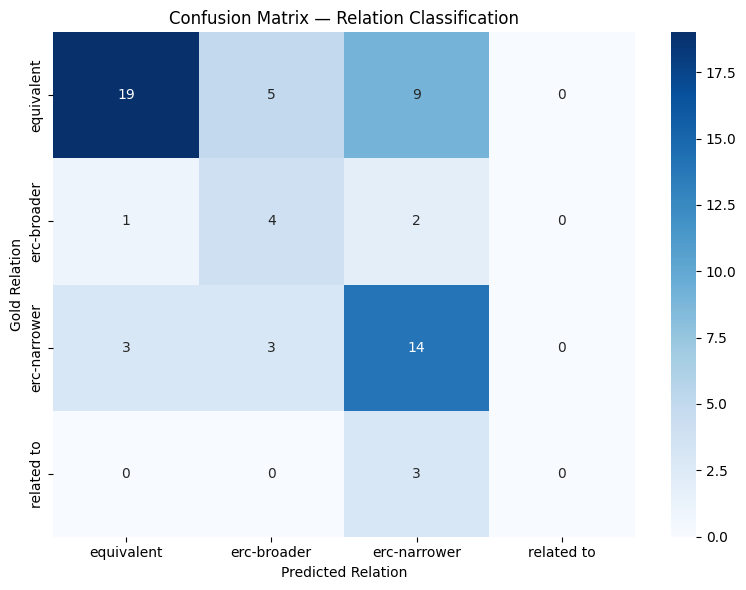

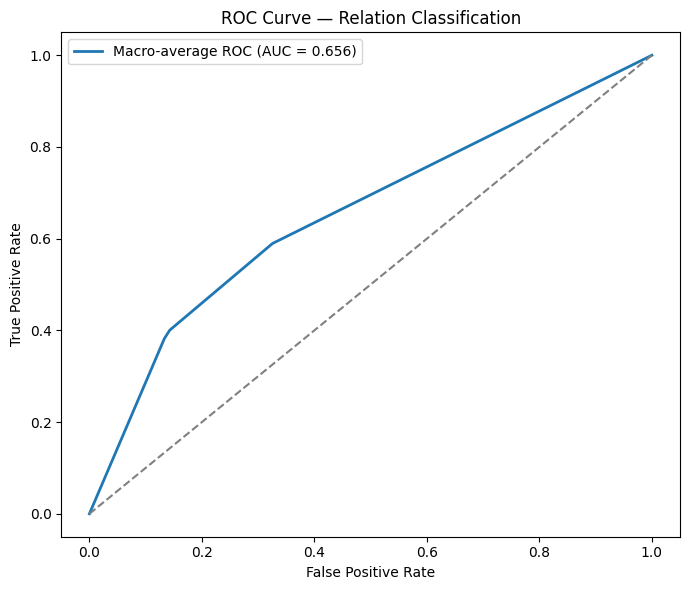


ROC AUC (macro-average): 0.656


In [4]:
# =========================
# CONFUSION MATRIX (RELATIONS)
# =========================
labels = sorted(set(df["REL_norm_gold"]) | set(df["REL_norm_pred"]))

cm = confusion_matrix(
    df["REL_norm_gold"],
    df["REL_norm_pred"],
    labels=labels
)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.title("Confusion Matrix — Relation Classification")
plt.xlabel("Predicted Relation")
plt.ylabel("Gold Relation")
plt.tight_layout()
plt.show()

# =========================
# ROC CURVE + AUC (MULTICLASS OvR)
# =========================
le = LabelEncoder()
y_true = le.fit_transform(df["REL_norm_gold"])
y_pred = le.transform(df["REL_norm_pred"])

classes = np.unique(y_true)

# Binarize
y_true_bin = label_binarize(y_true, classes=classes)
y_pred_bin = label_binarize(y_pred, classes=classes)

fpr = {}
tpr = {}
roc_auc = {}

for i, cls in enumerate(classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in classes]))
mean_tpr = np.zeros_like(all_fpr)

for i in classes:
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= len(classes)
macro_auc = auc(all_fpr, mean_tpr)

# Plot ROC
plt.figure(figsize=(7,6))
plt.plot(
    all_fpr,
    mean_tpr,
    label=f"Macro-average ROC (AUC = {macro_auc:.3f})",
    linewidth=2
)
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Relation Classification")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nROC AUC (macro-average): {macro_auc:.3f}")
